In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [5]:
df = pd.read_csv("stores_sales_forecasting.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [7]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day

In [8]:
le = LabelEncoder()

df['Category'] = le.fit_transform(df['Category'])
df['Region'] = le.fit_transform(df['Region'])
df['Segment'] = le.fit_transform(df['Segment'])
df['Sub-Category'] = le.fit_transform(df['Sub-Category'])

In [9]:
X = df[['Category', 'Region', 'Segment', 'Sub-Category', 'Year', 'Month', 'Day', 'Quantity', 'Discount']]
y = df['Sales']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

In [19]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [20]:
def evaluate(y_test, y_pred):
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))

In [14]:
print("Linear Regression Performance")
evaluate(y_test, y_pred_lr)

print("\nRandom Forest Performance")
evaluate(y_test, y_pred_rf)

Linear Regression Performance
MAE: 298.7327920187077
RMSE: 504.40427364939444
R2 Score: 0.16969018968022354

Random Forest Performance
MAE: 219.79457108224088
RMSE: 428.3007438791243
R2 Score: 0.4013399032542797


In [15]:
print("\nModel Comparison:")
print("LR R2:", r2_score(y_test, y_pred_lr))
print("RF R2:", r2_score(y_test, y_pred_rf))


Model Comparison:
LR R2: 0.16969018968022354
RF R2: 0.4013399032542797


<Axes: >

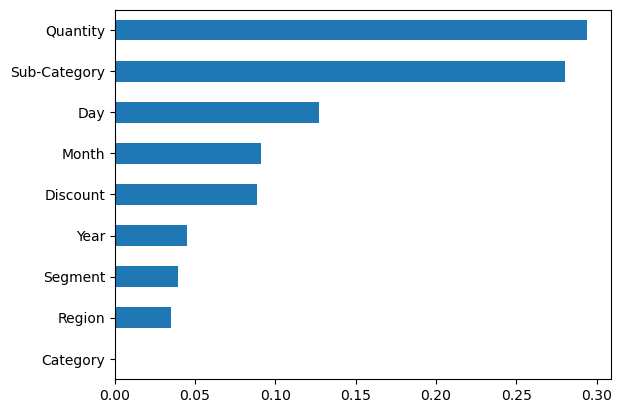

In [16]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

### Random Forest performs better and is suitable for future sales prediction

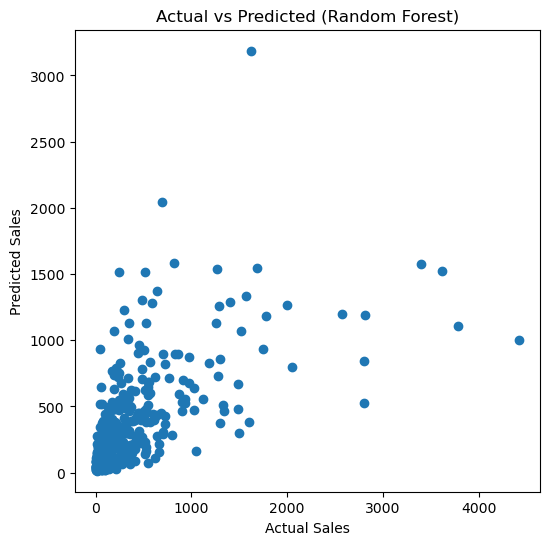

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted (Random Forest)")

plt.show()

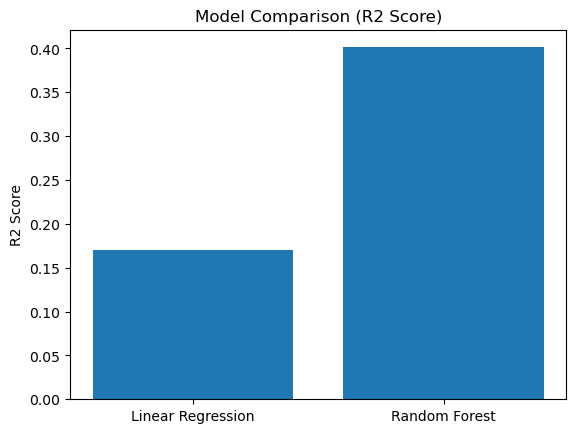

In [28]:
models = ['Linear Regression', 'Random Forest']
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_rf)
]

plt.bar(models, r2_scores)

plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")

plt.show()

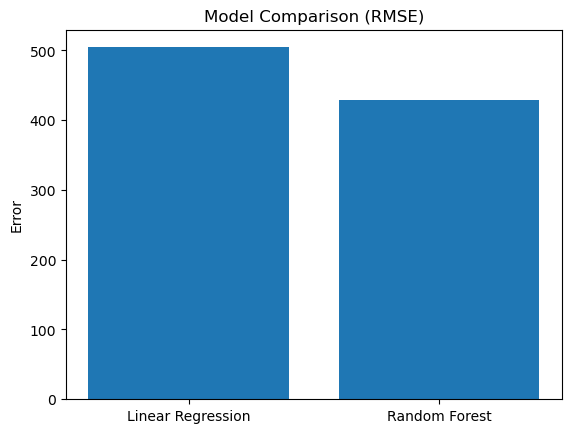

In [24]:
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

plt.bar(['Linear Regression', 'Random Forest'], [rmse_lr, rmse_rf])

plt.title("Model Comparison (RMSE)")
plt.ylabel("Error")

plt.show()

In [29]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ],
    'RMSE': [rmse_lr, rmse_rf]
})

print(results)

               Model  R2 Score        RMSE
0  Linear Regression   0.16969  504.404274
1      Random Forest   0.40134  428.300744


### 🟢 1. Random Forest Regressor performs better than Linear Regression due to higher R² score and lower error values, making it more suitable for sales prediction.

## 🟢 2. Business Recommendations

- Focus on high-performing product categories to increase revenue and strengthen market position.  
- Control excessive discount strategies to avoid negative impact on profitability.  
- Prioritize expansion and investment in top-performing regions.  
- Apply targeted marketing strategies to improve performance in low-performing regions.  
- Maintain adequate inventory for high-demand products to prevent stock shortages.  
- Use seasonal sales patterns for better planning of promotions and resource allocation.  
- Leverage data-driven insights to improve overall business efficiency and decision-making.  